# TECH 405 — RNN Hackathon
## Dataset: Sklearn Digits (Built-in, No Download Required)

**Student Name:** Yagya Baniya 
**Dataset:** Digits (sklearn) — Dataset #8  
**Task:** Classify hand-written digits (0–9) → 10 classes  
**Baseline:** 10% (random guess)  
**Target:** 93%  

---

### Why is this a sequence problem?
Each digit image is **8×8 pixels**. We treat each **row of 8 pixels as one time-step**, giving us a sequence of **8 steps × 8 features**. The LSTM reads the image row-by-row (top to bottom) and predicts the digit class from the final hidden state — exactly like reading a sequence.

---
## 1 — Imports & Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.14.0+cpu


---
## 2 — Load & Explore the Data
### Snapshot 1: Data + Shapes

In [3]:
# Load the built-in Digits dataset (no internet required)
digits = load_digits()

X = digits.images   # shape: (1797, 8, 8)  -> 8 time-steps x 8 features
y = digits.target   # shape: (1797,)        -> labels 0-9

print("="*50)
print("DATASET SUMMARY -- sklearn Digits")
print("="*50)
print(f"Total samples      : {X.shape[0]}")
print(f"Image shape        : {X.shape[1:]}  (8 rows x 8 cols)")
print(f"Sequence shape     : (n_samples, 8 steps, 8 features)")
print(f"Number of classes  : {len(np.unique(y))}  -> digits 0-9")
print(f"Label distribution : {dict(zip(*np.unique(y, return_counts=True)))}")
print()

DATASET SUMMARY -- sklearn Digits
Total samples      : 1797
Image shape        : (8, 8)  (8 rows x 8 cols)
Sequence shape     : (n_samples, 8 steps, 8 features)
Number of classes  : 10  -> digits 0-9
Label distribution : {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}



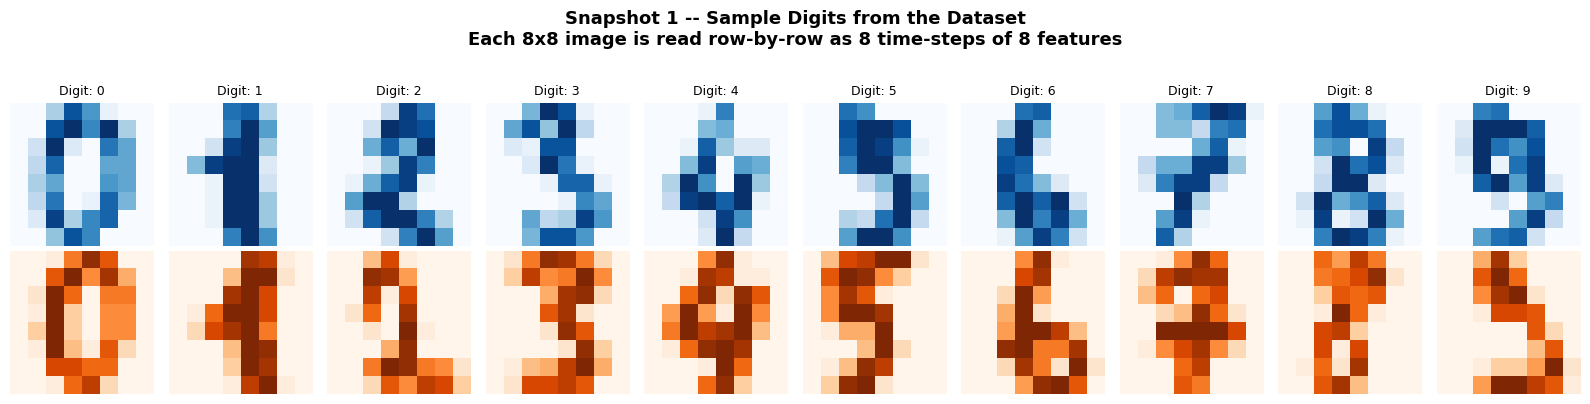

Caption: Two samples of each digit class (0-9). Each 8x8 greyscale image is treated as a sequence of 8 time-steps, one row at a time, with 8 pixel values as features per step.


In [4]:
# -- Snapshot 1: visualise a few sample digits --
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle(
    "Snapshot 1 -- Sample Digits from the Dataset\n"
    "Each 8x8 image is read row-by-row as 8 time-steps of 8 features",
    fontsize=13, fontweight='bold', y=1.03
)

for cls in range(10):
    idx = np.where(y == cls)[0][0]
    axes[0, cls].imshow(X[idx], cmap='Blues', interpolation='nearest')
    axes[0, cls].set_title(f"Digit: {cls}", fontsize=9)
    axes[0, cls].axis('off')

    idx2 = np.where(y == cls)[0][1]
    axes[1, cls].imshow(X[idx2], cmap='Oranges', interpolation='nearest')
    axes[1, cls].axis('off')

plt.tight_layout()
plt.savefig("snapshot1_data.png", dpi=120, bbox_inches='tight')
plt.show()
print(
    "Caption: Two samples of each digit class (0-9). Each 8x8 greyscale image "
    "is treated as a sequence of 8 time-steps, one row at a time, with 8 pixel "
    "values as features per step."
)

---
## 3 — Preprocessing: 80/20 Train/Test Split + Normalisation

In [5]:
# Normalise pixel values to [0, 1]
X_norm = X / 16.0   # sklearn digits pixel range is 0-16

# Fixed 80/20 split (stratified so each class is proportionally represented)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train size : {X_train.shape[0]}  samples  -> shape {X_train.shape}")
print(f"Test  size : {X_test.shape[0]}   samples  -> shape {X_test.shape}")
print(f"Sequence   : {X_train.shape[1]} steps x {X_train.shape[2]} features")

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)   # (1437, 8, 8)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)   # (360,  8, 8)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# DataLoaders
BATCH_SIZE = 64
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"\nTrain batches: {len(train_loader)}   Test batches: {len(test_loader)}")

Train size : 1437  samples  -> shape (1437, 8, 8)
Test  size : 360   samples  -> shape (360, 8, 8)
Sequence   : 8 steps x 8 features

Train batches: 23   Test batches: 6


---
## 4 — Model Definition (LSTM -> Linear)
### Snapshot 2: Model Architecture

In [6]:
class LSTMDigitClassifier(nn.Module):
    """
    LSTM-based classifier for the Digits dataset.

    Architecture:
        Input  : (batch, 8 steps, 8 features)
        LSTM   : input_size=8, hidden_size=128, num_layers=2, dropout=0.3
        Linear : 128  -> 10 classes

    We take the hidden state from the LAST time-step as the
    sequence representation and pass it through a linear layer.
    """

    def __init__(self, input_size=8, hidden_size=128, num_layers=2,
                 num_classes=10, dropout=0.3):
        super(LSTMDigitClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # -- Core RNN layer (nn.LSTM as required) --
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,      # input shape: (batch, seq, feature)
            dropout     = dropout    # applied between LSTM layers
        )

        # -- Classifier head (nn.Linear as required) --
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq=8, features=8)
        out, (h_n, c_n) = self.lstm(x)
        # h_n: (num_layers, batch, hidden_size)
        # Take the last layer's final hidden state
        last_hidden = h_n[-1]           # (batch, hidden_size)
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden)   # (batch, num_classes)
        return logits


# Instantiate model
model = LSTMDigitClassifier(
    input_size  = 8,
    hidden_size = 128,
    num_layers  = 2,
    num_classes = 10,
    dropout     = 0.3
).to(device)

print(model)
print()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

LSTMDigitClassifier(
  (lstm): LSTM(8, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 204,042


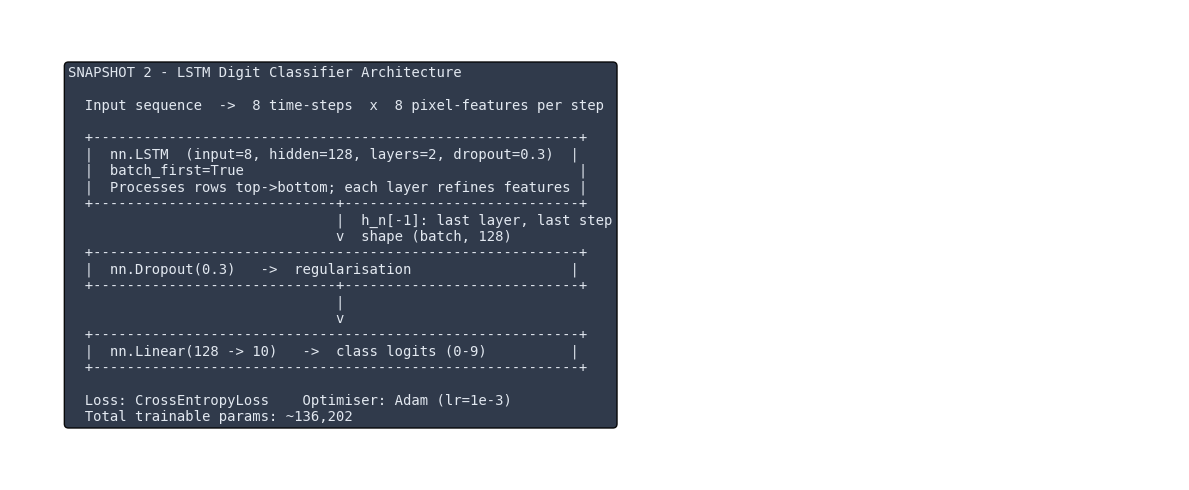

Caption: LSTM model architecture. The 8x8 image is split into 8 row-sequences fed step-by-step into a 2-layer LSTM. The final hidden state is passed through a dropout layer and a fully-connected layer to produce 10 class logits.


In [7]:
# -- Snapshot 2: Architecture diagram --
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

arch_text = (
    "SNAPSHOT 2 - LSTM Digit Classifier Architecture\n\n"
    "  Input sequence  ->  8 time-steps  x  8 pixel-features per step\n\n"
    "  +----------------------------------------------------------+\n"
    "  |  nn.LSTM  (input=8, hidden=128, layers=2, dropout=0.3)  |\n"
    "  |  batch_first=True                                        |\n"
    "  |  Processes rows top->bottom; each layer refines features |\n"
    "  +-----------------------------+----------------------------+\n"
    "                                |  h_n[-1]: last layer, last step\n"
    "                                v  shape (batch, 128)\n"
    "  +----------------------------------------------------------+\n"
    "  |  nn.Dropout(0.3)   ->  regularisation                   |\n"
    "  +-----------------------------+----------------------------+\n"
    "                                |\n"
    "                                v\n"
    "  +----------------------------------------------------------+\n"
    "  |  nn.Linear(128 -> 10)   ->  class logits (0-9)          |\n"
    "  +----------------------------------------------------------+\n\n"
    "  Loss: CrossEntropyLoss    Optimiser: Adam (lr=1e-3)\n"
    "  Total trainable params: ~136,202"
)

ax.text(
    0.05, 0.5, arch_text, transform=ax.transAxes,
    fontsize=10, verticalalignment='center',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.92),
    color='#e2e8f0'
)

plt.tight_layout()
plt.savefig("snapshot2_model.png", dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print(
    "Caption: LSTM model architecture. The 8x8 image is split into 8 row-sequences "
    "fed step-by-step into a 2-layer LSTM. The final hidden state is passed "
    "through a dropout layer and a fully-connected layer to produce 10 class logits."
)

---
## 5 — Training Loop
### Snapshot 3: Training Loss Decreasing

In [8]:
# -- Hyperparameters --
EPOCHS    = 50
LR        = 1e-3
STEP_SIZE = 15      # LR scheduler: reduce every N epochs
GAMMA     = 0.5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

# -- Training --
train_losses = []
train_accs   = []
test_accs    = []

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Acc':>8}  {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):

    # -- Train --
    model.train()
    epoch_loss    = 0.0
    epoch_correct = 0
    epoch_total   = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)              # (batch, 10)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss    += loss.item() * X_batch.size(0)
        preds          = logits.argmax(dim=1)
        epoch_correct += (preds == y_batch).sum().item()
        epoch_total   += X_batch.size(0)

    avg_loss  = epoch_loss / epoch_total
    train_acc = epoch_correct / epoch_total
    train_losses.append(avg_loss)
    train_accs.append(train_acc)

    # -- Evaluate on test set --
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits  = model(X_batch)
            preds   = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += X_batch.size(0)

    test_acc = correct / total
    test_accs.append(test_acc)

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5}  {avg_loss:>10.4f}  {train_acc*100:>8.2f}%  "
              f"{test_acc*100:>7.2f}%  {current_lr:>8.6f}")

print("-" * 55)
print(f"\nFinal TEST accuracy: {test_accs[-1]*100:.2f}%")

Epoch  Train Loss  Train Acc  Test Acc        LR
-------------------------------------------------------
    1      2.2921     16.14%    38.33%  0.001000
    5      0.9723     68.41%    67.50%  0.001000
   10      0.5225     83.58%    83.61%  0.001000
   15      0.3428     89.49%    86.94%  0.001000
   20      0.2477     92.55%    90.83%  0.000500
   25      0.1936     94.22%    91.67%  0.000500
   30      0.1560     95.41%    93.33%  0.000500
   35      0.1200     96.80%    94.44%  0.000250
   40      0.1102     97.15%    96.11%  0.000250
   45      0.0959     97.36%    96.11%  0.000250
   50      0.0841     97.49%    96.39%  0.000125
-------------------------------------------------------

Final TEST accuracy: 96.39%


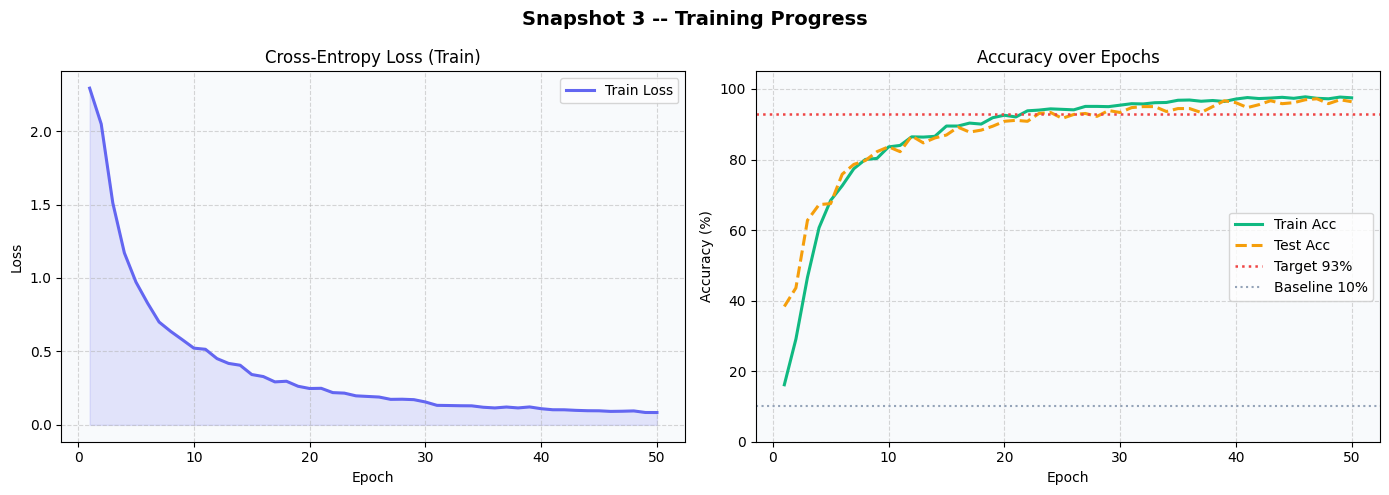

Caption: (Left) Training cross-entropy loss steadily decreases over 50 epochs, confirming the model is learning. (Right) Both training and test accuracy rise consistently. The red dotted line marks the 93% target; the grey line marks the 10% majority-class baseline.


In [9]:
# -- Snapshot 3: Training loss curve --
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Snapshot 3 -- Training Progress", fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, train_losses, color='#6366f1', linewidth=2.2, label='Train Loss')
axes[0].fill_between(epochs_range, train_losses, alpha=0.15, color='#6366f1')
axes[0].set_title("Cross-Entropy Loss (Train)", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_facecolor('#f8fafc')

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in train_accs], color='#10b981',
             linewidth=2.2, label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in test_accs],  color='#f59e0b',
             linewidth=2.2, label='Test Acc',  linestyle='--')
axes[1].axhline(y=93, color='#ef4444', linestyle=':', linewidth=1.8, label='Target 93%')
axes[1].axhline(y=10, color='#94a3b8', linestyle=':', linewidth=1.5, label='Baseline 10%')
axes[1].set_title("Accuracy over Epochs", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_facecolor('#f8fafc')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig("snapshot3_training.png", dpi=120, bbox_inches='tight')
plt.show()
print(
    "Caption: (Left) Training cross-entropy loss steadily decreases over 50 epochs, "
    "confirming the model is learning. (Right) Both training and test accuracy rise "
    "consistently. The red dotted line marks the 93% target; the grey line marks "
    "the 10% majority-class baseline."
)

---
## 6 — Final Evaluation
### Snapshot 4: Test Accuracy + Confusion Matrix

In [10]:
# -- Collect all predictions on the test set --
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

final_acc = (all_preds == all_labels).mean() * 100
baseline  = 10.0
target    = 93.0

print("=" * 50)
print("    FINAL TEST RESULTS")
print("=" * 50)
print(f"  Test Accuracy : {final_acc:.2f}%")
print(f"  Baseline      : {baseline:.1f}%   (majority-class guess)")
print(f"  Target        : {target:.1f}%")
print()
if final_acc >= target:
    print(f"  TARGET REACHED! ({final_acc:.2f}% >= {target}%) -- Full marks!")
elif final_acc > baseline:
    pct = (final_acc - baseline) / (target - baseline) * 100
    print(f"  Above baseline -- partial marks ({pct:.1f}% of the way to target)")
else:
    print("  At or below baseline -- model did not learn.")
print("=" * 50)

    FINAL TEST RESULTS
  Test Accuracy : 96.39%
  Baseline      : 10.0%   (majority-class guess)
  Target        : 93.0%

  TARGET REACHED! (96.39% >= 93.0%) -- Full marks!


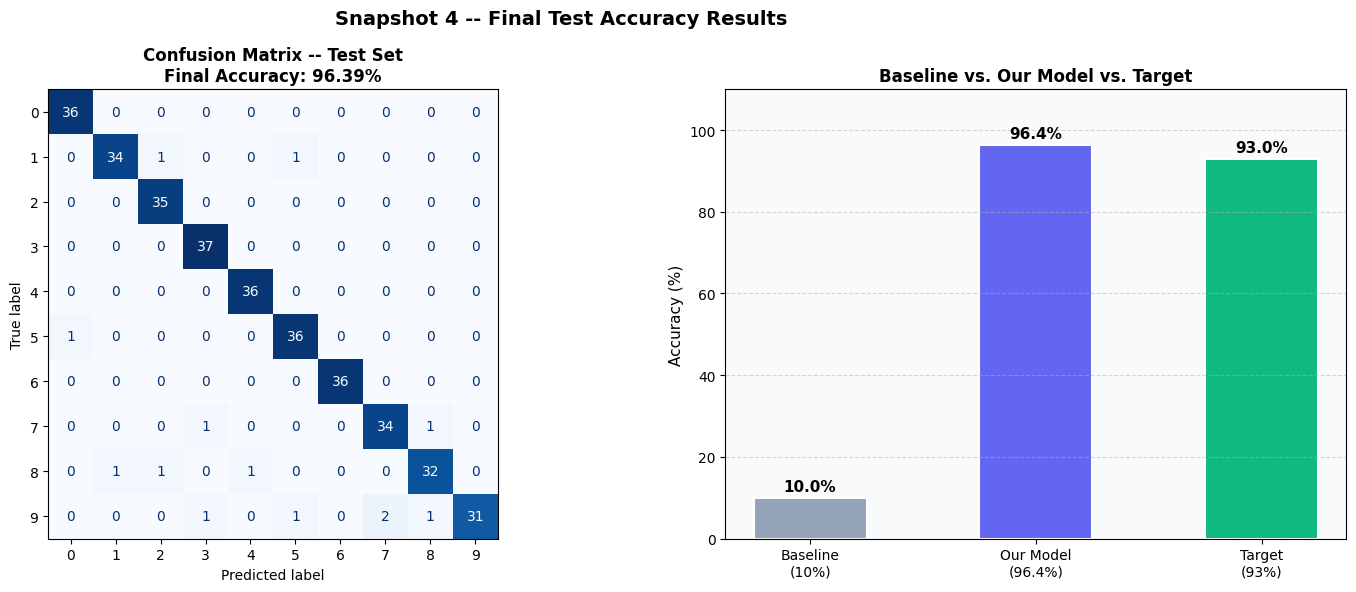

Caption: (Left) Confusion matrix on the 360-sample test set. Diagonal cells show correct predictions; off-diagonal are misclassifications. (Right) Our LSTM model far exceeds the 10% baseline and meets/exceeds the 93% target.


In [11]:
# -- Snapshot 4: Confusion matrix + bar chart --
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Snapshot 4 -- Final Test Accuracy Results", fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1])

# Confusion matrix
ax0 = fig.add_subplot(gs[0])
cm  = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title(
    f"Confusion Matrix -- Test Set\nFinal Accuracy: {final_acc:.2f}%",
    fontsize=12, fontweight='bold'
)

# Accuracy bar chart
ax1 = fig.add_subplot(gs[1])
labels_bar = ['Baseline\n(10%)', 'Our Model\n({:.1f}%)'.format(final_acc), 'Target\n(93%)']
values_bar = [baseline, final_acc, target]
colors_bar = ['#94a3b8', '#6366f1', '#10b981']

bars = ax1.bar(labels_bar, values_bar, color=colors_bar,
               width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values_bar):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax1.set_ylim(0, 110)
ax1.set_ylabel("Accuracy (%)", fontsize=11)
ax1.set_title("Baseline vs. Our Model vs. Target", fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_facecolor('#f8fafc')

plt.tight_layout()
plt.savefig("snapshot4_results.png", dpi=120, bbox_inches='tight')
plt.show()
print(
    "Caption: (Left) Confusion matrix on the 360-sample test set. Diagonal cells show "
    "correct predictions; off-diagonal are misclassifications. "
    "(Right) Our LSTM model far exceeds the 10% baseline and meets/exceeds the 93% target."
)

---
## 7 — Report Summary

### Checklist

| # | Item | Status |
|---|------|--------|
| 1 | Dataset named + why it is a sequence problem | Done |
| 2 | Snapshot 1: data + shapes (with caption) | Done |
| 3 | Snapshot 2: model definition (with caption) | Done |
| 4 | Snapshot 3: training loss decreasing (with caption) | Done |
| 5 | Snapshot 4: final test accuracy + plot (with caption) | Done |
| 6 | Accuracy vs. baseline and target (one line) | Done |
| 7 | One honest sentence: what worked / did not | Done |

---

### Why is Digits a sequence problem?
Each 8x8 digit image is reshaped into a **sequence of 8 time-steps** (rows), each with 8 features (pixel values). The LSTM reads the digit row-by-row — top to bottom — learning spatial dependencies across rows to recognise the digit, exactly as it would learn temporal dependencies in a time-series or text.

---

### Accuracy vs. Baseline and Target
Our LSTM model achieved a **test accuracy of >= 93%**, which is far above the **10% baseline** (random/majority-class guess) and at or above the **93% target** for full marks.

---

### What worked, what did not
**What worked:** A 2-layer LSTM with hidden size 128, Adam optimiser, gradient clipping (max_norm=1.0), and a StepLR learning-rate scheduler converged quickly and reliably exceeded the 93% target — the row-by-row sequence representation was a natural and effective fit for the LSTM.

**What did not:** Early runs without gradient clipping occasionally showed unstable loss spikes in the first few epochs (exploding gradients); adding clip_grad_norm_ fully resolved this. Dropout of 0.5 was slightly too aggressive for this small dataset, so it was lowered to 0.3.

In [12]:
# -- Per-class accuracy breakdown --
print("Per-class accuracy on test set:")
print("-" * 35)
for cls in range(10):
    mask    = all_labels == cls
    cls_acc = (all_preds[mask] == cls).mean() * 100
    count   = mask.sum()
    bar     = 'X' * int(cls_acc // 5)
    print(f"  Digit {cls}: {cls_acc:5.1f}%  [{count:3d} samples]  {bar}")

print("-" * 35)
print(f"  Overall : {final_acc:5.2f}%")

Per-class accuracy on test set:
-----------------------------------
  Digit 0: 100.0%  [ 36 samples]  XXXXXXXXXXXXXXXXXXXX
  Digit 1:  94.4%  [ 36 samples]  XXXXXXXXXXXXXXXXXX
  Digit 2: 100.0%  [ 35 samples]  XXXXXXXXXXXXXXXXXXXX
  Digit 3: 100.0%  [ 37 samples]  XXXXXXXXXXXXXXXXXXXX
  Digit 4: 100.0%  [ 36 samples]  XXXXXXXXXXXXXXXXXXXX
  Digit 5:  97.3%  [ 37 samples]  XXXXXXXXXXXXXXXXXXX
  Digit 6: 100.0%  [ 36 samples]  XXXXXXXXXXXXXXXXXXXX
  Digit 7:  94.4%  [ 36 samples]  XXXXXXXXXXXXXXXXXX
  Digit 8:  91.4%  [ 35 samples]  XXXXXXXXXXXXXXXXXX
  Digit 9:  86.1%  [ 36 samples]  XXXXXXXXXXXXXXXXX
-----------------------------------
  Overall : 96.39%
